In [1]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from utils.evaluation import evaluate_pipeline
from utils import column_type_split, feature_importance_df
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv("../data/train_clear.csv")

In [3]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [4]:
columns = column_type_split(X)

In [5]:
def get_pipeline(model) -> Pipeline:
    return Pipeline(
        [
            (
                "preprocess",
                ColumnTransformer(
                    [
                        (
                            "ordinal",
                            OrdinalEncoder(
                                handle_unknown="use_encoded_value",
                                unknown_value=-1,
                                dtype=np.int64,
                            ),
                            columns.categorical,
                        )
                    ],
                    remainder="passthrough",
                ),
            ),
            (model.__class__.__name__, model),
        ]
    )

Модель DecisionTreeClassifier
F1-macro: 0.718 ± 0.005
F1-weighted: 0.791 ± 0.004


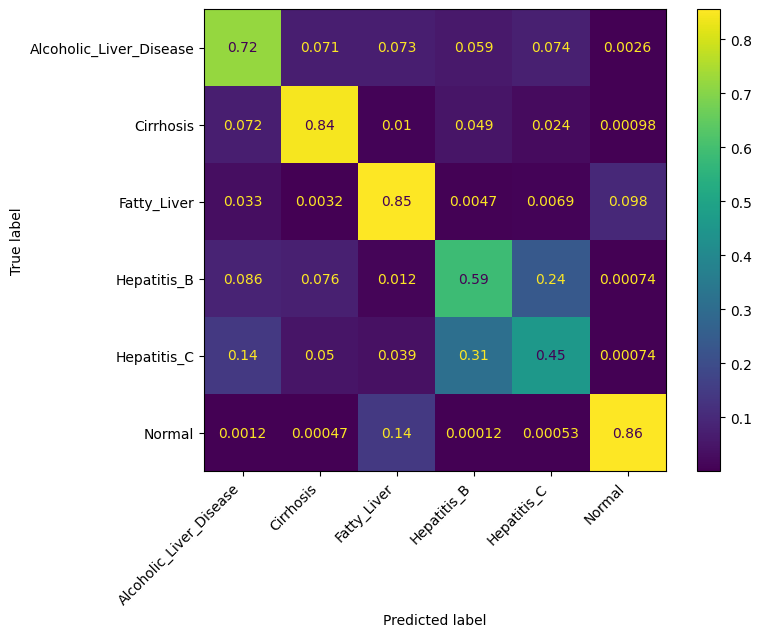

In [6]:
evaluate_pipeline(get_pipeline(DecisionTreeClassifier()), X, y)

In [7]:
forest_pipeline = get_pipeline(RandomForestClassifier())

0 fold: fitting
0 fold: scoring
1 fold: fitting
1 fold: scoring
2 fold: fitting
2 fold: scoring
3 fold: fitting
3 fold: scoring
4 fold: fitting
4 fold: scoring
Модель RandomForestClassifier
F1-macro: 0.793 ± 0.005
F1-weighted: 0.856 ± 0.003


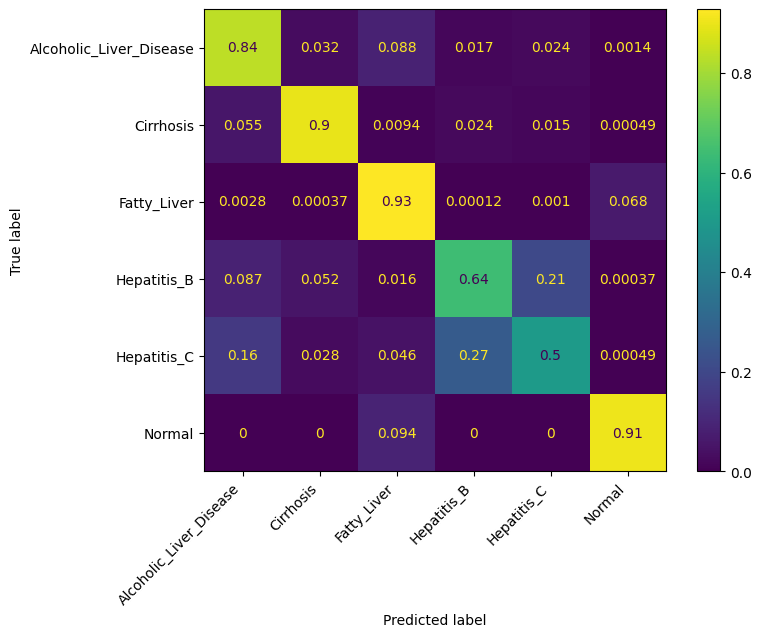

In [8]:
feature_importance = evaluate_pipeline(forest_pipeline, X, y, additional="feature_importances_", verbose=True)

In [9]:
names = forest_pipeline[0].get_feature_names_out()
feature_importance_df(feature_importance, names).head(10)

,feature,importance
22,remainder__Bilirubin,0.151632
21,remainder__AST,0.149405
20,remainder__ALT,0.142111
23,remainder__Albumin,0.078194
24,remainder__Platelets,0.062622
11,remainder__Sym_Jaundice,0.056357
10,remainder__Sym_Fatigue,0.055741
15,remainder__Sym_Dark_Urine,0.047504
14,remainder__Sym_Ascites,0.028647
17,remainder__Comorb_Diabetes,0.026699


И одно дерево решений, и лес дали высокую точность. Важными признаками стали ферменты и симптомы